# QNMs of NS (Lindblom & Detweiler, AJSS 53, 73, 1983)

This notebook reproduces the TOV and perturbation calculations translated from Mathematica to Julia. We start using standard `Float64` (`T = Float64`) which provides ~16 digits of precision and runs enormously fast. If you need stricter numerical stability (e.g., 20+ digits), simply change `T` to `BigFloat`!

In [1]:
# Install packages if not already present
#import Pkg
#Pkg.add("DifferentialEquations")
using DifferentialEquations

# Setup precision type. Change to BigFloat for higher precision if required.
T = Float64
# If using BigFloat, you can set the precision (e.g., 67 bits is ~20 decimal digits):
# setprecision(BigFloat, 67)
# T = BigFloat

Float64

## Constants and Parameters

In [2]:
# Constants
gc2 = T(7.42365e-29)
G = T(6.6732e-8)
cc = T(2.9979e10)
Msun = T(1.47664)

# Integration cutoff parameters
ϵ0 = T(1e-6)
ϵsurf = T(1e-12)

1.0e-12

## Equation of State (Polytropic)

In [3]:
function ρ_eos(p1::T) where {T}
    K = T(100) * Msun^2
    γ0 = T(2)
    ρb = (p1 / K)^(T(1)/γ0)
    return ρb + p1
end

function cs2_eos(p1::T) where {T}
    K = T(100) * Msun^2
    γ0 = T(2)
    ρb = (p1 / K)^(T(1)/γ0)
    return T(1) / ( (ρb / γ0) / p1 + T(1) )
end

cs2_eos (generic function with 1 method)

## TOV Integration

In [4]:
function tov_derivatives!(du, u, p_params, x)
    r_var, m_var, νb_var = u
    
    p_val = exp(x)
    ρ_val = ρ_eos(p_val)
    
    # Standard TOV equations with respect to r
    dmdr = 4 * T(pi) * r_var^2 * ρ_val
    dνdr = 2 * (m_var + 4 * T(pi) * r_var^3 * p_val) / (r_var * (r_var - 2 * m_var))
    dpdr = -(ρ_val + p_val) / 2 * dνdr
    
    # Convert derivatives to x = ln(p)
    drdx = p_val / dpdr
    dmdx = drdx * dmdr
    dνbdx = drdx * dνdr
    
    du[1] = drdx
    du[2] = dmdx
    du[3] = dνbdx
end

function solve_tov(p0_val::T)
    h1 = ϵ0 * p0_val
    x0 = log(p0_val - h1)
    
    ρ0 = ρ_eos(p0_val)
    
    r0 = sqrt(2 * h1 / (4 * T(pi) * (ρ0 + p0_val) * (ρ0/3 + p0_val)))
    m0 = (4 * T(pi) / 3) * ρ0 * r0^3
    νb0 = T(0)
    
    xf = log(ϵsurf * p0_val)
    
    u0 = [r0, m0, νb0]
    tspan = (x0, xf)
    
    prob = ODEProblem(tov_derivatives!, u0, tspan)
    # Abs/Rel tolerances adjusted for standard Float64 vs BigFloat automatically based on T
    tol = T == Float64 ? 1e-10 : T(10)^(-16)
    sol = solve(prob, Tsit5(), reltol=tol, abstol=tol)
    
    r_f, m_f, νb_f = sol.u[end]
    
    M_tov = m_f
    R_tov = r_f
    ν0 = -νb_f + log(1 - 2 * M_tov / R_tov)
    
    # We return the solution interpolant and boundary values for perturbations
    return (; sol, x0, xf, M_tov, R_tov, ν0)
end

# Test TOV Integration
p0_test = T(0.751e-4)
tov_result = solve_tov(p0_test)

println("TOV Mass (M/Msun): ", tov_result.M_tov / Msun)
println("TOV Radius (R): ", tov_result.R_tov)

TOV Mass (M/Msun): 1.400029689036349
TOV Radius (R): 14.155265877585398


## Lindblom & Detweiler Perturbation Integration

In [5]:
function pert_derivatives!(du, u, p_params, x)
    # Unpacking parameters
    tov_sol, l, omega = p_params
    omega2 = omega^2
    
    # Extract TOV background values at x
    r_var, m_var, νb_var = tov_sol(x)
    ν_var = νb_var + tov_result.ν0
    p_val = exp(x)
    ρ_val = ρ_eos(p_val)
    cs2_val = cs2_eos(p_val)
    
    # Variables needed for coefficients
    el = T(1) / (1 - 2 * m_var / r_var)
    en = exp(ν_var)
    en2 = exp(ν_var / 2)
    el2 = sqrt(abs(el))
    
    dνdr = 2 * (m_var + 4 * T(pi) * r_var^3 * p_val) / (r_var * (r_var - 2 * m_var))
    dpdr = -(ρ_val + p_val) / 2 * dνdr
    νp = dνdr
    
    drdx = p_val / dpdr
    
    # --- Double Solutions (a) and (b) ---
    # State: [H1a, Ka, Wa, Xa, H1b, Kb, Wb, Xb]
    H1a, Ka, Wa, Xa, H1b, Kb, Wb, Xb = u
    
    # Helper coefficient calculation function
    function get_derivs(H1X, KX, WX, XX)
        DD = el2 * (4 * T(pi) * (ρ_val + 3 * p_val) - νp / el * (νp + 8/r_var)/4)
        EE = XX / cs2_val
        
        H0 = (8 * T(pi) * r_var^3 / en2 * XX - 
             (l * (l+1) / 2 * (m_var + 4 * T(pi) * p_val * r_var^3) - omega2 * (r_var^3 / el) / en) * H1X + 
             ((l+2) * (l-1) / 2 * r_var - omega2 * (r_var^3 / en) - el/r_var * (m_var + 4 * T(pi) * p_val * r_var^3) * (3*m_var - r_var + 4 * T(pi) * p_val * r_var^3)) * KX
             ) / (3 * m_var + (l+2)*(l-1)/2 * r_var + 4 * T(pi) * p_val * r_var^3)
             
        V = en2 / omega2 * (XX / (ρ_val + p_val) - νp / (2 * r_var) * (en2 / el2) * WX - en2 / 2 * H0)
        
        dH1dr = -T(1)/r_var * (l + 1 + 2 * m_var * el / r_var + 4 * T(pi) * r_var^2 * el * (p_val - ρ_val)) * H1X + el/r_var * (H0 + KX - 16 * T(pi) * (ρ_val + p_val) * V)
        
        dKdr = H0/r_var + l * (l+1) / (2 * r_var) * H1X - ((l+1)/r_var - νp/2)*KX - 8 * T(pi) * (ρ_val + p_val) * el2/r_var * WX
        
        dWdr = -(l+1)/r_var * WX + r_var * el2 * (EE / (ρ_val + p_val) / en2 - l*(l+1)/r_var^2 * V + H0/2 + KX)
        
        dXdr = -l/r_var * XX + (ρ_val + p_val) * en2 * ((1/r_var - νp/2) * H0/2 + 
               1/2 * (r_var * omega2 / en + l*(l+1)/2/r_var) * H1X +
               1/2 * (3/2 * νp - 1/r_var) * KX - l*(l+1)/2 * νp/r_var^2 * V -
               1/r_var * (4 * T(pi)*(ρ_val + p_val)*el2 + omega2 * el2 / en - DD)*WX)
               
        return dH1dr, dKdr, dWdr, dXdr
    end
    
    dH1adr, dKadr, dWadr, dXadr = get_derivs(H1a, Ka, Wa, Xa)
    dH1bdr, dKbdr, dWbdr, dXbdr = get_derivs(H1b, Kb, Wb, Xb)
    
    du[1] = drdx * dH1adr
    du[2] = drdx * dKadr
    du[3] = drdx * dWadr
    du[4] = drdx * dXadr
    du[5] = drdx * dH1bdr
    du[6] = drdx * dKbdr
    du[7] = drdx * dWbdr
    du[8] = drdx * dXbdr
end

function solve_ld(p0_val::T, l::Int, omega::T)
    # 1. Background Run
    tov = solve_tov(p0_val)
    tov_sol = tov.sol
    x0 = tov.x0
    xf = tov.xf
    
    p0_act = exp(x0)
    ρ0 = ρ_eos(p0_act)
    r0_var, m0_var, νb0_var = tov_sol(x0)
    ν0_var = νb0_var + tov.ν0
    en0 = exp(ν0_var)
    en02 = exp(ν0_var / 2)
    
    # 2. Setup Central Boundary Conditions for Perturbations
    W0a = T(1)
    K0a = T(1)
    W0b = T(1)
    K0b = T(-1)
    
    X0a = (ρ0 + p0_act) * en02 * ((4 * T(pi)*(ρ0/3 + p0_act) - (omega^2/en0)/l) * W0a + K0a/2)
    H10a = (2 * l * K0a + 16 * T(pi)*(ρ0 + p0_act)*W0a)/l / (l+1)
    
    X0b = (ρ0 + p0_act) * en02 * ((4 * T(pi)*(ρ0/3 + p0_act) - (omega^2/en0)/l) * W0b + K0b/2)
    H10b = (2 * l * K0b + 16 * T(pi)*(ρ0 + p0_act)*W0b)/l / (l+1)
    
    u0 = [H10a, K0a, W0a, X0a, H10b, K0b, W0b, X0b]
    tspan = (x0, xf)
    params = (tov_sol, l, omega)
    
    prob = ODEProblem(pert_derivatives!, u0, tspan, params)
    tol = T == Float64 ? 1e-10 : T(10)^(-13)
    sol = solve(prob, Tsit5(), reltol=tol, abstol=tol)
    
    return (; sol, tov)
end

solve_ld (generic function with 1 method)

## Matching to Zerilli Function (Surface)

In [6]:
function eval_zeta(p0_val::T, l::Int, omega::T)
    ld_run = solve_ld(p0_val, l, omega)
    ld_sol = ld_run.sol
    xf = ld_run.tov.xf
    M = ld_run.tov.M_tov
    R = ld_run.tov.R_tov
    
    # Get Surface Values
    u_surf = ld_sol(xf)
    H1aS, KaS, WaS, XaS, H1bS, KbS, WbS, XbS = u_surf
    
    CC = -XaS / XbS
    
    H1S = H1aS + CC * H1bS
    KS  = KaS  + CC * KbS
    
    # Zerilli Constants
    n = (l-1)*(l+2)/2
    c11 = R^2 / (n*R + 3*M)
    c12 = -R^2 * (1 - 2*M/R) / (n*R + 3*M)
    c21 = -(n*R^2 - 3*M*(n*R + M)) / (n*R + 3*M)^2
    c22 = (1 - 2*M/R) * (n*(n+1)*R^2 + 3*M*(n*R + 2*M)) / (n*R + 3*M)^2
    
    Zer = R^l * (c11 * KS + c12 * H1S)
    DZer = R^l * (c21 * KS + c22 * H1S)
    
    zeta = 2 * M * DZer / Zer
    return zeta
end

# Test Zeta extraction for specific omega
z_test = eval_zeta(p0_test, 2, T(0.004))
println("Zeta value for omega = 0.004: ", z_test)

Zeta value for omega = 0.004: 0.09417859704050943


## QNM Frequency Sweep

In [ ]:
# This mimics the Do-loop near the end of the notebook
println("Sweeping through omega table...")
for i in 1:20
    omega = T(0.004) + T(i - 1) * T(0.0005)
    try
        z_val = eval_zeta(p0_test, 2, omega)
        println("i=$i, omega=$omega, zeta=$z_val")
    catch e
        println("i=$i, omega=$omega failed with error: ", e)
    end
end

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\Arun KG\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\Arun KG\.julia\environments\v1.12\Manifest.toml`


Computing zeta across range 1e-3 to 1 ...


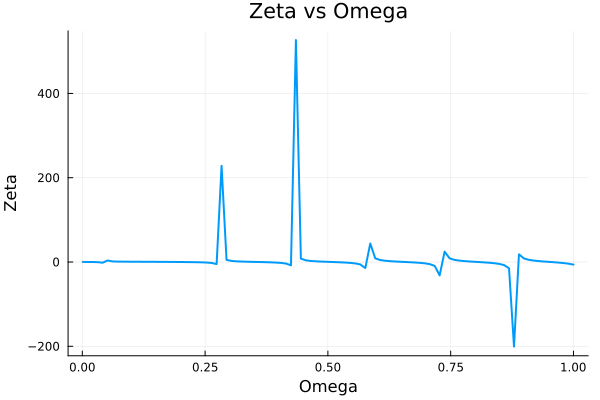

In [7]:
Pkg.add("Plots")
using Plots

# Generate an array of omega values from 1e-3 to 1
omega_range = range(T(1e-3), T(1), length=100)
zeta_vals = zeros(T, length(omega_range))

println("Computing zeta across range 1e-3 to 1 ...")
for (i, om) in enumerate(omega_range)
    try
        zeta_vals[i] = eval_zeta(p0_test, 2, om)
    catch e
        zeta_vals[i] = NaN
    end
end

# Plot the results
plot(omega_range, zeta_vals, 
     xlabel="Omega", 
     ylabel="Zeta", 
     title="Zeta vs Omega", 
     linewidth=2, 
     legend=false,
     yformatter=:plain)

In [27]:


# In the original Mathematica notebook, `TT1` covered exactly 20 points
# where omega = 0.004 + (i-1)*0.0005 for i = 1 to 20.
omega_mathematica = [T(0.004) + T(i-1)*T(0.0005) for i in 1:20]

x_vals = zeros(T, length(omega_mathematica))
zeta_vals = zeros(T, length(omega_mathematica))

println("Computing TT1 zeta values across zoomed region [0.004, 0.0135] ...")
for (i, om) in enumerate(omega_mathematica)
    try
        zeta_val = eval_zeta(p0_test, 2, om)
        x_vals[i] = om  # This is TT1[[i, 1]]
        zeta_vals[i] = zeta_val     # This is TT1[[i, 2]]
        println("i=$i, omega=$om, 2*M*omega=$(x_vals[i]), zeta=$zeta_val")
    catch e
        x_vals[i] = NaN
        zeta_vals[i] = NaN
    end
end


Computing TT1 zeta values across zoomed region [0.004, 0.0135] ...
i=1, omega=0.004, 2*M*omega=0.004, zeta=0.09417859704050943
i=2, omega=0.0045000000000000005, 2*M*omega=0.0045000000000000005, zeta=0.09307510024253071
i=3, omega=0.005, 2*M*omega=0.005, zeta=0.0918369927578221
i=4, omega=0.0055, 2*M*omega=0.0055, zeta=0.09046264086013092
i=5, omega=0.006, 2*M*omega=0.006, zeta=0.0889502184554026
i=6, omega=0.006500000000000001, 2*M*omega=0.006500000000000001, zeta=0.08729770063610806
i=7, omega=0.007, 2*M*omega=0.007, zeta=0.08550285645620813
i=8, omega=0.0075, 2*M*omega=0.0075, zeta=0.08356324088235252
i=9, omega=0.008, 2*M*omega=0.008, zeta=0.08147618586016395
i=10, omega=0.0085, 2*M*omega=0.0085, zeta=0.07923879043877805
i=11, omega=0.009000000000000001, 2*M*omega=0.009000000000000001, zeta=0.07684790988182268
i=12, omega=0.0095, 2*M*omega=0.0095, zeta=0.07430014368045587
i=13, omega=0.01, 2*M*omega=0.01, zeta=0.07159182239218782
i=14, omega=0.0105, 2*M*omega=0.0105, zeta=0.06871899

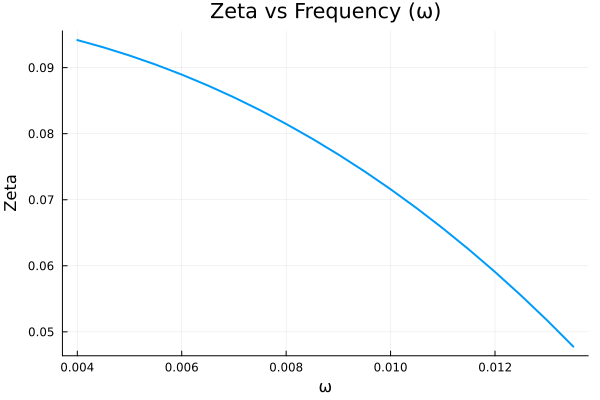

In [29]:
plot(x_vals, zeta_vals, xlabel="ω", ylabel="Zeta", title="Zeta vs Frequency (ω)", linewidth=2, legend=false)

In [9]:
z_test = eval_zeta(p0_test, 2, T(0.004))
println("Zeta value for omega = 0.004: ", z_test)

Zeta value for omega = 0.004: 0.09417859704050943


In [10]:
omega_mathematica

20-element Vector{Float64}:
 0.004
 0.0045000000000000005
 0.005
 0.0055
 0.006
 0.006500000000000001
 0.007
 0.0075
 0.008
 0.0085
 0.009000000000000001
 0.0095
 0.01
 0.0105
 0.011
 0.0115
 0.012
 0.0125
 0.013000000000000001
 0.0135

In [12]:
omega_mathematica = [T(0.004) + T(i-1)*T(0.0005) for i in 1:20]

x_vals = zeros(T, length(omega_mathematica))
zeta_vals = zeros(T, length(omega_mathematica))

println("Computing TT1 zeta values across zoomed region [0.004, 0.0135] ...")
for (i, om) in enumerate(omega_mathematica)
    try
        zeta_val, M_val = eval_zeta(p0_test, 2, om)
        x_vals[i] = 2 * M_val * om  # This is TT1[[i, 1]]
        zeta_vals[i] = zeta_val     # This is TT1[[i, 2]]
        println("i=$i, omega=$om, 2*M*omega=$(x_vals[i]), zeta=$zeta_val")
    catch e
        x_vals[i] = NaN
        zeta_vals[i] = NaN
    end
end

Computing TT1 zeta values across zoomed region [0.004, 0.0135] ...


In [16]:
omega_mathematica

20-element Vector{Float64}:
 0.004
 0.0045000000000000005
 0.005
 0.0055
 0.006
 0.006500000000000001
 0.007
 0.0075
 0.008
 0.0085
 0.009000000000000001
 0.0095
 0.01
 0.0105
 0.011
 0.0115
 0.012
 0.0125
 0.013000000000000001
 0.0135

In [23]:

for (i, om) in enumerate(omega_mathematica)
    try
        zeta_val= eval_zeta(p0_test, 2, om)
        println("i=$i, omega=$om, zeta=$zeta_val")
    catch e
        println("ERROR for omega=$om: ", e)
    end
end

i=1, omega=0.004, zeta=0.09417859704050943
i=2, omega=0.0045000000000000005, zeta=0.09307510024253071
i=3, omega=0.005, zeta=0.0918369927578221
i=4, omega=0.0055, zeta=0.09046264086013092
i=5, omega=0.006, zeta=0.0889502184554026
i=6, omega=0.006500000000000001, zeta=0.08729770063610806
i=7, omega=0.007, zeta=0.08550285645620813
i=8, omega=0.0075, zeta=0.08356324088235252
i=9, omega=0.008, zeta=0.08147618586016395
i=10, omega=0.0085, zeta=0.07923879043877805
i=11, omega=0.009000000000000001, zeta=0.07684790988182268
i=12, omega=0.0095, zeta=0.07430014368045587
i=13, omega=0.01, zeta=0.07159182239218782
i=14, omega=0.0105, zeta=0.06871899319219282
i=15, omega=0.011, zeta=0.06567740403876207
i=16, omega=0.0115, zeta=0.062462486321533534
i=17, omega=0.012, zeta=0.05906933585527459
i=18, omega=0.0125, zeta=0.05549269206714406
i=19, omega=0.013000000000000001, zeta=0.05172691519819376
i=20, omega=0.0135, zeta=0.047765961325125915


7.51e-5

In [ ]:
for i in omega_mathematica
    try 
        zeta_val = 

20-element Vector{Float64}:
 0.004
 0.0045000000000000005
 0.005
 0.0055
 0.006
 0.006500000000000001
 0.007
 0.0075
 0.008
 0.0085
 0.009000000000000001
 0.0095
 0.01
 0.0105
 0.011
 0.0115
 0.012
 0.0125
 0.013000000000000001
 0.0135

In [20]:
eval_zeta(p0_test, 2, T(0.0135))

0.047765961325125915

# Modified

In [2]:
# Constants
gc2 = T(7.42365e-29)
G = T(6.6732e-8)
cc = T(2.9979e10)
Msun = T(1.47664)

# Integration cutoff parameters
ϵ0 = T(1e-6)
ϵsurf = T(1e-12)

function ρ_eos(p1::T) where {T}
    K = T(100) * Msun^2
    γ0 = T(2)
    ρb = (p1 / K)^(T(1)/γ0)
    return ρb + p1
end

function cs2_eos(p1::T) where {T}
    K = T(100) * Msun^2
    γ0 = T(2)
    ρb = (p1 / K)^(T(1)/γ0)
    return T(1) / ( (ρb / γ0) / p1 + T(1) )
end

function tov_derivatives!(du, u, p_params, x)
    r_var, m_var, νb_var = u
    
    p_val = exp(x)
    ρ_val = ρ_eos(p_val)
    
    # Standard TOV equations with respect to r
    dmdr = 4 * T(pi) * r_var^2 * ρ_val
    dνdr = 2 * (m_var + 4 * T(pi) * r_var^3 * p_val) / (r_var * (r_var - 2 * m_var))
    dpdr = -(ρ_val + p_val) / 2 * dνdr
    
    # Convert derivatives to x = ln(p)
    drdx = p_val / dpdr
    dmdx = drdx * dmdr
    dνbdx = drdx * dνdr
    
    du[1] = drdx
    du[2] = dmdx
    du[3] = dνbdx
end

function solve_tov(p0_val::T)
    h1 = ϵ0 * p0_val
    x0 = log(p0_val - h1)
    
    ρ0 = ρ_eos(p0_val)
    
    r0 = sqrt(2 * h1 / (4 * T(pi) * (ρ0 + p0_val) * (ρ0/3 + p0_val)))
    m0 = (4 * T(pi) / 3) * ρ0 * r0^3
    νb0 = T(0)
    
    xf = log(ϵsurf * p0_val)
    
    u0 = [r0, m0, νb0]
    tspan = (x0, xf)
    
    prob = ODEProblem(tov_derivatives!, u0, tspan)
    # Abs/Rel tolerances adjusted for standard Float64 vs BigFloat automatically based on T
    tol = T == Float64 ? 1e-10 : T(10)^(-16)
    sol = solve(prob, Tsit5(), reltol=tol, abstol=tol)
    
    r_f, m_f, νb_f = sol.u[end]
    
    M_tov = m_f
    R_tov = r_f
    ν0 = -νb_f + log(1 - 2 * M_tov / R_tov)
    
    # We return the solution interpolant and boundary values for perturbations
    return (; sol, x0, xf, M_tov, R_tov, ν0)
end

solve_tov (generic function with 1 method)

In [3]:
# Shooting method to find p0 for a required compactness
function target_compactness_func(p0_val::T, target_C::T)
    tov = solve_tov(p0_val)
    return (tov.M_tov / tov.R_tov) - target_C
end

function find_p0_for_compactness(target_C::T, p0_guess1::T, p0_guess2::T; tol::T=T(1e-8), max_iter::Int=50)
    p0_0 = p0_guess1
    p0_1 = p0_guess2
    f0 = target_compactness_func(p0_0, target_C)
    f1 = target_compactness_func(p0_1, target_C)
    
    for i in 1:max_iter
        if abs(f1) < tol
            return p0_1
        end
        # Secant step
        p0_new = p0_1 - f1 * (p0_1 - p0_0) / (f1 - f0)
        p0_0 = p0_1
        f0 = f1
        p0_1 = p0_new
        f1 = target_compactness_func(p0_1, target_C)
    end
    println("Warning: Max iterations reached in shooting method.")
    return p0_1
end

# Set desired compactness here
target_C = T(0.14) # This roughly corresponds to the old p0_test C
p0_test = find_p0_for_compactness(target_C, T(1e-5), T(1e-4))
tov_result = solve_tov(p0_test)

println("Target Compactness: ", target_C)
println("Calculated p0: ", p0_test)
println("TOV Mass (M/Msun): ", tov_result.M_tov / Msun)
println("TOV Radius (R): ", tov_result.R_tov)
println("Achieved Compactness: ", tov_result.M_tov / tov_result.R_tov)


Target Compactness: 0.14
Calculated p0: 6.4643698065927e-5
TOV Mass (M/Msun): 1.3623304038089763
TOV Radius (R): 14.369082624566907
Achieved Compactness: 0.1400000000028617


Sweeping compactness values to generate M-R curve...
Successfully mapped 20 compactness points.


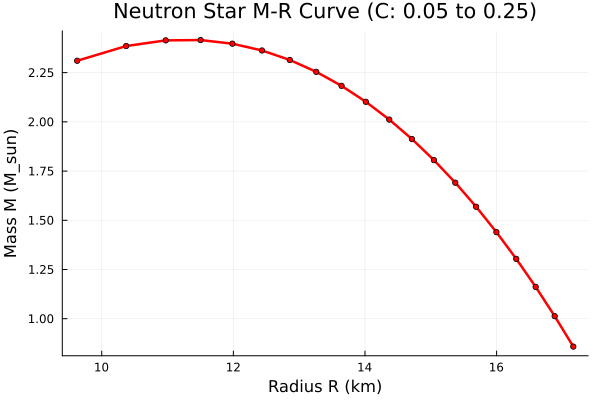

In [5]:
# -------------------------------------------------------------
# Generate a Mass-Radius plot parameterized by Compactness
# -------------------------------------------------------------
using Plots

# Define the range of compactness values you want to sweep (e.g. 50 points)
C_range = range(T(0.05), T(0.24), length=20)

masses = T[]
radii = T[]

println("Sweeping compactness values to generate M-R curve...")

# Base starting guesses for the secant method
g1 = T(1e-6)
g2 = T(1e-5)

for target_C in C_range
    try
        p0_val = find_p0_for_compactness(target_C, g1, g2; tol=T(1e-6), max_iter=100)
        tov_res = solve_tov(p0_val)
        
        M_solar = tov_res.M_tov #/ Msun
        R_km = tov_res.R_tov
        achieved_C = tov_res.M_tov / tov_res.R_tov
        
        # Ensure that the shooting method converged accurately
        if abs(achieved_C - target_C) < 1e-3
            push!(masses, M_solar)
            push!(radii, R_km)
            
            # Step our guesses forward for the subsequent target
            g1 = g2
            g2 = p0_val
        end
    catch e
        # If target compactness pushes past maximum mass thresholds for this EOS,
        # it might throw a domain error. Let it fail gracefully and skip that point.
    end
end

println("Successfully mapped ", length(masses), " compactness points.")

# Create the Mass-Radius plot
plot(radii, masses, 
     xlabel="Radius R (km)", 
     ylabel="Mass M (M_sun)", 
     title="Neutron Star M-R Curve (C: 0.05 to 0.25)", 
     linewidth=2.5,
     color=:red,
     marker=:circle,
     markersize=3,
     legend=false)


In [6]:
function pert_derivatives!(du, u, p_params, x)
    # Unpack parameters (now including the local ν0 offset)
    tov_sol, l, omega, ν0_offset = p_params
    om = omega
    
    # Extract TOV background values at x
    r, m, νb = tov_sol(x)
    ν = νb + ν0_offset
    p0 = exp(x)
    eps = ρ_eos(p0)
    cs2 = cs2_eos(p0)
    
    # Background derivatives w.r.t r
    nu_p = 2 * (m + 4 * T(pi) * r^3 * p0) / (r * (r - 2 * m))
    p_prime = -(eps + p0) / 2 * nu_p
    
    # The transformation factor from d/dr to d/dx
    drdx = p0 / p_prime
    
    lam = -log(1 - 2 * m / r)
    
    # Evaluate exponentials once
    exp_lam = exp(lam)
    exp_nu = exp(ν)
    
    # Helper to calculate d/dr derivatives for a given solution vector
    function get_derivs(X, W, H1, K)
        # Source terms - set to zero for the perfect fluid limit as you requested.
        # This is where your evaluated functions (e.g. S01(r)) will be called in the future.
        S01  = T(0)
        S01p = T(0)
        S00  = T(0)
        S0A  = T(0)
        SZ   = T(0)
        S0   = T(0)
        S0p  = T(0)
        S1   = T(0)
        S1p  = T(0)
        SOm  = T(0)

        Eh = X / cs2
        Hdenom = r * (2*r + 3*m + 4*T(pi)*r^3 * p0) 

        # Extended Equations
        H = (8*exp(-ν/2)*T(pi)*r^4 *X + 2*r^2 *K - exp(-ν)*r^4 *om^2 *K + 
             exp(-lam)*r*K*m - 3*exp(-lam)*K*m^2 + 4*exp(-lam)*T(pi)*r^4 *K*p0 - 
             16*exp(-lam)*T(pi)^2 *r^6 *K*p0^2 + 
             H1*(-3*r*m + r^4 *(exp(-lam-ν)*om^2 - 12*T(pi)*p0)) - 
             8*T(pi)*r^2 *S0 - 16*exp(-lam)*T(pi)*r^2 *S1) / Hdenom

        Vhnum1 = exp(-lam + ν/2) * (-4*S1 - exp(lam)*(2*(S1 - 2*SZ + SOm) + 
                 r^2*(8*T(pi)*S1*(p0 - eps) + H*(eps + p0))) + 
                 2*exp(lam/2)*r*W*p_prime - 2*r*S1p) / r^2
                 
        Vh = exp(ν/2) * (2*X + Vhnum1) / (2 * om^2 * (eps + p0))
        
        dH1dr = (exp(lam) / r) * H + 
                (4 * T(pi) * r * (eps - p0) * exp(lam) - (2 * m * exp(lam) / r^2) - (3 / r)) * H1 + 
                (exp(lam) / r) * K - 
                16 * T(pi) * ((eps + p0) / r) * exp(lam) * Vh + 
                16 * T(pi) * (exp(lam) / r) * SZ

        dKdr = (H / r) + 
               (l * (l + 1) / (2 * r)) * H1 + 
               ((nu_p / 2) - ((l + 1) / r)) * K - 
               8 * T(pi) * ((eps + p0) / r) * exp(lam / 2) * W + 
               (16 * T(pi) / r) * SZ

        dWhdr = (r / 2) * exp(lam / 2) * H + 
                r * exp(lam / 2) * K + 
                (r * exp((lam - ν) / 2) / (eps + p0)) * Eh - 
                W * (l + 1) / r - 
                (l * (l + 1) / r) * exp(lam / 2) * Vh - 
                exp(lam / 2) * S00 / (r * (eps + p0)) + 
                8 * T(pi) * r * exp(lam / 2) * SZ

        dXhdr = ((eps + p0) / 2) * exp(ν / 2) * ((1 / r) - (nu_p / 2)) * H + 
                ((eps + p0) / 2) * exp(ν / 2) * (om^2 * r * exp(-ν) + (l * (l + 1) / (2 * r))) * H1 + 
                ((eps + p0) / 2) * exp(ν / 2) * ((3 * nu_p / 2) - (1 / r)) * K - 
                (l / r) * X - 
                ((eps + p0) / r) * exp((lam + ν) / 2) * (om^2 * exp(-ν) + (exp(-lam) / (4 * r^2)) * (exp(2 * lam) * (1 + 8 * T(pi) * r^2 * p0)^2 + 2 * exp(lam) * (3 + 8 * T(pi) * r^2 * p0 ) - 7 )) * W + 
                (l * (l + 1) / r^2) * exp(ν / 2) * p_prime * Vh + 
                (exp(ν / 2) / (2 * r^3)) * (2 * l - 1 + exp(lam) * (1 + 8 * T(pi) * r^2 * p0)) * S0 + 
                (exp(ν / 2) / r^2) * S0p - 
                (exp(ν / 2) / r^3) * (l * (l + 1) + 8 * T(pi) * r^2 * (eps + p0)) * S1 - 
                (2 * exp(ν / 2) / r^3) * SOm
        
        # Returned in correct order [H1, K, W, X] corresponding to main state vector
        return dH1dr, dKdr, dWhdr, dXhdr
    end
    
    # Unpack state: [H1a, Ka, Wa, Xa, H1b, Kb, Wb, Xb]
    H1a, Ka, Wa, Xa, H1b, Kb, Wb, Xb = u
    
    # Compute ODEs mapped from r-derivatives (pass X, W, H1, K explicitly)
    dH1adr, dKadr, dWadr, dXadr = get_derivs(Xa, Wa, H1a, Ka)
    dH1bdr, dKbdr, dWbdr, dXbdr = get_derivs(Xb, Wb, H1b, Kb)
    
    # Scale by dr/dx to integrate with respect to x
    du[1] = drdx * dH1adr
    du[2] = drdx * dKadr
    du[3] = drdx * dWadr
    du[4] = drdx * dXadr
    du[5] = drdx * dH1bdr
    du[6] = drdx * dKbdr
    du[7] = drdx * dWbdr
    du[8] = drdx * dXbdr
end


function solve_ld(p0_val::T, l::Int, omega::T)
    # 1. Background Run
    tov = solve_tov(p0_val)
    tov_sol = tov.sol
    x0 = tov.x0
    xf = tov.xf
    
    p0_act = exp(x0)
    ρ0 = ρ_eos(p0_act)
    r0_var, m0_var, νb0_var = tov_sol(x0)
    ν0_var = νb0_var + tov.ν0
    en0 = exp(ν0_var)
    en02 = exp(ν0_var / 2)
    
    # 2. Setup Central Boundary Conditions for Perturbations
    W0a = T(1)
    K0a = T(1)
    W0b = T(1)
    K0b = T(-1)
    
    X0a = (ρ0 + p0_act) * en02 * ((4 * T(pi)*(ρ0/3 + p0_act) - (omega^2/en0)/l) * W0a + K0a/2)
    H10a = (2 * l * K0a + 16 * T(pi)*(ρ0 + p0_act)*W0a)/l / (l+1)
    
    X0b = (ρ0 + p0_act) * en02 * ((4 * T(pi)*(ρ0/3 + p0_act) - (omega^2/en0)/l) * W0b + K0b/2)
    H10b = (2 * l * K0b + 16 * T(pi)*(ρ0 + p0_act)*W0b)/l / (l+1)
    
    u0 = [H10a, K0a, W0a, X0a, H10b, K0b, W0b, X0b]
    tspan = (x0, xf)
    
    # IMPORTANT: We now pass tov.ν0 so the integration uses the correct local offset!
    params = (tov_sol, l, omega, tov.ν0)
    
    prob = ODEProblem(pert_derivatives!, u0, tspan, params)
    tol = T == Float64 ? 1e-10 : T(10)^(-13)
    sol = solve(prob, Tsit5(), reltol=tol, abstol=tol)
    
    return (; sol, tov)
end


solve_ld (generic function with 1 method)